# Tutorial 3: Using CauST with STAGATE

This notebook demonstrates how CauST acts as a **preprocessing plug-in** that improves STAGATE's domain identification by providing causally filtered gene sets.

## Pipeline

```
Raw AnnData → CauST (causal gene selection) → STAGATE (graph attention autoencoder) → Domain labels
```

CauST selects the genes that *causally drive* spatial structure, then passes only those genes to STAGATE. Neither CauST nor STAGATE needs to be modified — they compose naturally.

### Prerequisites

```bash
pip install -e .            # CauST
pip install STAGATE-pyG     # STAGATE (optional; this tutorial works without it)
```

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

from caust import CauST
from caust.data.loader import load_and_preprocess
from caust.evaluate.metrics import evaluate_single_slice, compute_ari

/workspace/CauST/caust_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Create Synthetic Data

We simulate a tissue slice with 5 spatial domains and known marker genes.

In [2]:
def make_tissue(n_obs=400, n_vars=250, n_domains=5, seed=42):
    rng = np.random.default_rng(seed)
    obs_per = n_obs // n_domains

    X_parts, coord_parts = [], []
    for i in range(n_domains):
        base = rng.poisson(lam=5, size=(obs_per, n_vars)).astype(np.float32)
        # 15 marker genes per domain
        marker_start = i * 15
        base[:, marker_start:marker_start + 15] += 8 * (i + 1)
        X_parts.append(base)
        angle = 2 * np.pi * i / n_domains
        centre = [15 * np.cos(angle), 15 * np.sin(angle)]
        coord_parts.append(rng.normal(centre, 2, (obs_per, 2)))

    X = np.vstack(X_parts)
    adata = ad.AnnData(X=csr_matrix(X))
    adata.obs_names = [f'spot_{i}' for i in range(X.shape[0])]
    adata.var_names = [f'gene_{j}' for j in range(n_vars)]
    adata.obsm['spatial'] = np.vstack(coord_parts)
    adata.obs['ground_truth'] = np.repeat(np.arange(n_domains), obs_per).astype(str)
    return adata

adata = make_tissue()
print(f'Tissue: {adata.n_obs} spots × {adata.n_vars} genes, {len(np.unique(adata.obs["ground_truth"]))} domains')

Tissue: 400 spots × 250 genes, 5 domains


## 2. Preprocess

In [3]:
adata_pp = load_and_preprocess(adata, n_top_genes=150, min_genes=10, min_cells=1)
print(f'Preprocessed: {adata_pp.n_obs} spots × {adata_pp.n_vars} genes')

[loader] Received AnnData directly
         Raw shape: 400 spots × 250 genes
         After QC : 400 spots × 250 genes


         HVGs selected: 150
         Final shape : 400 spots × 150 genes

Preprocessed: 400 spots × 150 genes


## 3. Baseline — Run CauST Alone (Internal Clustering)

In [4]:
model = CauST(
    n_causal_genes=60, n_clusters=5, epochs=80,
    scoring_method='gradient', filter_mode='filter_and_reweight', verbose=True,
)
adata_caust = model.fit_transform(adata_pp.copy())

labels_pred = adata_caust.obs['caust_domain'].astype(int).values
labels_true = adata_pp.obs.loc[adata_caust.obs_names, 'ground_truth'].values
latent_Z = adata_caust.obsm['caust_latent']
metrics_caust = evaluate_single_slice(labels_pred, latent_Z, labels_true)
print('\nCauST-Internal metrics:')
for k, v in metrics_caust.items():
    print(f'  {k}: {v:.4f}')


  CauST initialized
  device         : cuda
  n_causal_genes : 60
  filter_mode    : filter_and_reweight
  scoring_method : gradient
  intervention   : mean_impute
  alpha          : 0.5

[graph] Building KNN graph: 400 spots, k=6 neighbours
[graph] Edges: 3,112  (avg degree 7.8)

Step 1/3 — Training spatial autoencoder …


    Training:   0%|                                                                                                     | 0/80 [00:00<?]

    Training:   0%|                                                                                                     | 0/80 [00:00<?]

    Training:   1%|█▏                                                                                               | 1/80 [00:00<00:18]

    Training:   1%|█▏                                                                                               | 1/80 [00:00<00:18]

...

    Training:  91%|███████████████████████████████████████████████████████████████████████████████████████▌        | 73/80 [00:00<00:00]

    Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00]

  Training complete. Final loss: 0.743977
Step 2/3 — Computing causal gene scores …
[scorer] Gradient scoring done. Top-5: gene_234(1.000), gene_84(0.866), gene_155(0.799), gene_181(0.732), gene_127(0.725)


Step 3/3 — Fitting complete.
[filter] Hard filter: 60 / 150 genes kept  (requested k=60)
[filter] Soft reweight: 60 genes reweighted (0 genes with zero score effectively silenced)
[filter] CauST filter+reweight: 60 genes, expression reweighted by causal score.



CauST-Internal metrics:
  silhouette: 0.7231
  ari: 1.0000
  nmi: 1.0000


## 4. CauST + STAGATE Integration

CauST filters the genes, then STAGATE builds its own graph attention autoencoder on the filtered data.

In [5]:
# Check if STAGATE is installed
try:
    import STAGATE_pyG  # noqa: F401  – only checking availability
    from caust.models.stagate_wrapper import run_with_stagate
    STAGATE_AVAILABLE = True
    print('STAGATE is installed — will run integration.')
except ImportError:
    STAGATE_AVAILABLE = False
    print('STAGATE not installed. Showing how the API works (dry run).')
    print('Install with: pip install STAGATE-pyG')

STAGATE not installed. Showing how the API works (dry run).
Install with: pip install STAGATE-pyG


In [6]:
if STAGATE_AVAILABLE:
    # CauST has already filtered genes in adata_caust
    # Now pass it to STAGATE
    adata_stagate = run_with_stagate(
        adata_caust.copy(),
        hidden_dims=[512, 30],
        n_epochs=200,
        verbose=True,
    )
    print(f'STAGATE latent stored in adata.obsm["STAGATE"]: {adata_stagate.obsm["STAGATE"].shape}')
else:
    # Show the API usage even without STAGATE installed
    print("""
    # How you would use it:
    from caust.models.stagate_wrapper import run_with_stagate

    adata_stagate = run_with_stagate(
        adata_caust,           # CauST-filtered AnnData
        hidden_dims=[512, 30],
        n_epochs=500,
        verbose=True,
    )
    # STAGATE latent vectors → adata_stagate.obsm['STAGATE']
    # Then cluster with mclust or Leiden:
    import scanpy as sc
    sc.pp.neighbors(adata_stagate, use_rep='STAGATE')
    sc.tl.leiden(adata_stagate, resolution=0.5)
    """)


    # How you would use it:
    from caust.models.stagate_wrapper import run_with_stagate

    adata_stagate = run_with_stagate(
        adata_caust,           # CauST-filtered AnnData
        hidden_dims=[512, 30],
        n_epochs=500,
        verbose=True,
    )
    # STAGATE latent vectors → adata_stagate.obsm['STAGATE']
    # Then cluster with mclust or Leiden:
    import scanpy as sc
    sc.pp.neighbors(adata_stagate, use_rep='STAGATE')
    sc.tl.leiden(adata_stagate, resolution=0.5)
    


## 5. CauST + GraphST Integration

Same principle — CauST selects genes, GraphST does the rest.

In [7]:
try:
    import GraphST  # noqa: F401 — check availability
    from caust.models.stagate_wrapper import run_with_graphst
    GRAPHST_AVAILABLE = True
except ImportError:
    GRAPHST_AVAILABLE = False

if GRAPHST_AVAILABLE:
    adata_graphst = run_with_graphst(adata_caust.copy(), n_domains=5)
    print('GraphST completed.')
else:
    print('GraphST not installed. API usage:')
    print("""
    from caust.models.stagate_wrapper import run_with_graphst
    adata_graphst = run_with_graphst(adata_caust, n_domains=5)
    """)

GraphST not installed. API usage:

    from caust.models.stagate_wrapper import run_with_graphst
    adata_graphst = run_with_graphst(adata_caust, n_domains=5)
    


## 6. Inspect Which Genes CauST Selected

Understanding *why* CauST chose certain genes is important for biological interpretation.

In [8]:
top = model.get_top_causal_genes(n=15)
print('Top 15 causal genes given to STAGATE/GraphST:')
for gene, score in top:
    print(f'  {gene}: {score:.4f}')

# The causal scores in adata.var
if 'causal_score' in adata_caust.var.columns:
    print(f'\nCausal scores stored in adata_caust.var["causal_score"]:')
    print(adata_caust.var['causal_score'].describe())

Top 15 causal genes given to STAGATE/GraphST:
  gene_234: 1.0000
  gene_84: 0.8661
  gene_155: 0.7993
  gene_181: 0.7320
  gene_127: 0.7251
  gene_108: 0.7234
  gene_205: 0.7035
  gene_99: 0.7006
  gene_211: 0.7004
  gene_130: 0.6871
  gene_32: 0.6814
  gene_200: 0.6801
  gene_98: 0.6711
  gene_123: 0.6633
  gene_179: 0.6583

Causal scores stored in adata_caust.var["causal_score"]:
count    60.000000
mean      0.604544
std       0.093941
min       0.514373
25%       0.533793
50%       0.569056
75%       0.656535
max       1.000000
Name: causal_score, dtype: float64


## 7. Visualize Domains Side-by-Side

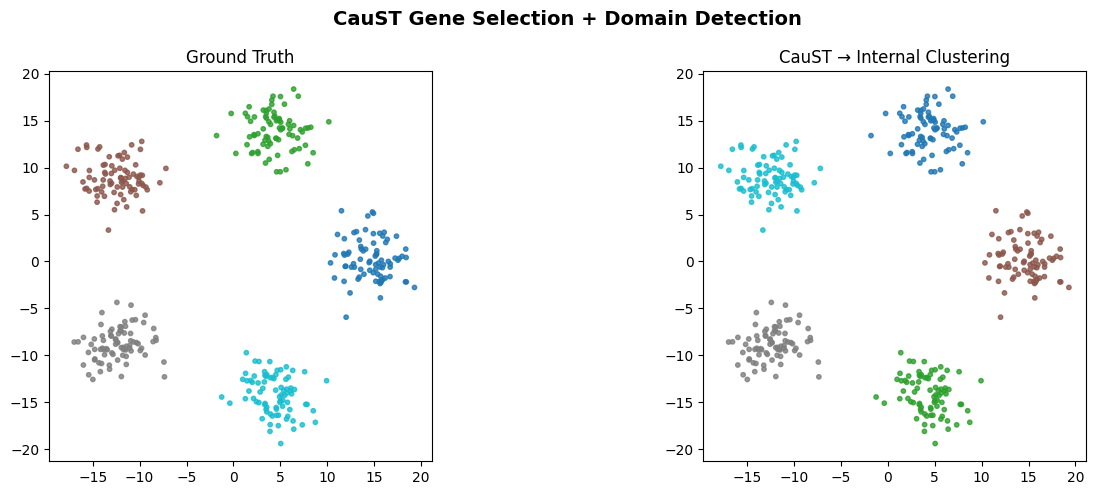

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
coords = adata_pp.obsm['spatial']

# Ground truth
ax = axes[0]
gt = adata_pp.obs['ground_truth'].astype(int).values
ax.scatter(coords[:, 0], coords[:, 1], c=gt, cmap='tab10', s=10, alpha=0.8)
ax.set_title('Ground Truth')
ax.set_aspect('equal')

# CauST domains
ax = axes[1]
pred = adata_caust.obs['caust_domain'].astype(int).values
ax.scatter(coords[:len(pred), 0], coords[:len(pred), 1], c=pred, cmap='tab10', s=10, alpha=0.8)
ax.set_title('CauST → Internal Clustering')
ax.set_aspect('equal')

plt.suptitle('CauST Gene Selection + Domain Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Step | Tool | What it does |
|------|------|-------------|
| Gene selection | **CauST** | Identifies causally important genes via in-silico interventions |
| Domain detection | **STAGATE** or **GraphST** | Builds spatial graph autoencoder on CauST-filtered genes |
| Evaluation | CauST metrics | ARI, NMI, Silhouette against ground truth |

CauST is method-agnostic — it works with *any* downstream spatial method that accepts an AnnData with gene expression and spatial coordinates.